# Rastermap on continuous activity: does the ordering of V1 neurons follow the stimulus, and does it differ between BTBR and C57BL/6J?

Trial-averaged analyses (OSI/DSI, noise correlations) cannot show how activity is organised across the whole recording, including the intervals between stimuli. Rastermap sorts neurons so that those with similar activity over time end up next to each other, without ever seeing the stimulus labels. Whether the resulting blocks line up with stimulus presentations is then something we test against the data instead of assuming.

**Scope.** One Rastermap fit per animal. Neurons from different animals never share a matrix. The genotype comparison stays qualitative in this notebook; any number extracted from an embedding has to be summarised per animal and go through the hierarchical bootstrap (Saravanan et al. 2020).

In [1]:
from pathlib import Path

# ─── PATHS ───────────────────────────────────────────────
DATA_ROOT = r'D:/AL-205/Nicole/Calcio/Nueva_carpeta'   # <-- change this

SCOPE_KEYWORD  = 'reg'      # TXT, microscope log
STIM_KEYWORD   = 'pas'      # TXT, stimulus log
TRACES_KEYWORD = 'traces'   # CSV, CaImAn raw fluorescence

GENOTYPE_FOLDERS = {'BTBR': 'BTBR', 'C57': 'C57'}

# ─── ACQUISITION ─────────────────────────────────────────
SAMPLING_RATE = 5                       # Hz
MS_PER_FRAME  = 1000 / SAMPLING_RATE    # 200 ms nominal; ~190 ms in the hardware counter (unresolved)
STIM_SEC      = 4                       # stimulus duration
STIM_FRAMES   = int(STIM_SEC * SAMPLING_RATE)

# ─── OUTPUT ──────────────────────────────────────────────
OUTPUT_DIR = Path(DATA_ROOT) / 'pipeline_output_rastermap'
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Which recordings exist, and can every file be found without ambiguity?

File lookup filters by extension and raises if more than one file matches, instead of taking the first. A folder that matches no known genotype raises instead of defaulting to `'Unknown'`. Output folders (`pipeline_output*`) inside `DATA_ROOT` are skipped, otherwise they would be read as genotype groups.

In [2]:
import pandas as pd

# Folders inside DATA_ROOT that are outputs, not genotype groups
IGNORE_PREFIXES = ('.', 'pipeline_output', 'rastermap_output')

def detect_genotype(group_name: str) -> str:
    for kw, geno in GENOTYPE_FOLDERS.items():
        if kw.upper() in group_name.upper():
            return geno
    raise ValueError(f"Folder '{group_name}' matches no genotype in {list(GENOTYPE_FOLDERS)}. "
                     f"If it is an output folder, add its prefix to IGNORE_PREFIXES.")


def find_file(folder: Path, keyword: str, suffix: str, exclude: tuple = ()) -> Path:
    kw = keyword.lower()
    ex = [e.lower() for e in exclude]
    matches = [f for f in folder.iterdir()
               if f.is_file() and kw in f.name.lower() and f.suffix.lower() == suffix
               and not any(e in f.name.lower() for e in ex)]
    if not matches:
        raise FileNotFoundError(f"No '{suffix}' file containing '{keyword}' in {folder}")
    if len(matches) > 1:
        raise ValueError(f"{len(matches)} candidates for '{keyword}' in {folder}: "
                         f"{[m.name for m in matches]}. Resolve manually.")
    return matches[0]


def discover_subjects(root) -> list:
    root = Path(root)
    subjects = []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith(IGNORE_PREFIXES):
            continue
        genotype = detect_genotype(group.name)
        for subject in sorted(group.iterdir()):
            if not subject.is_dir() or subject.name.startswith('.'):
                continue
            subjects.append({
                'subject_id': subject.name,
                'genotype':   genotype,
                'group':      group.name,
                'folder':     subject,
                'files': {
                    'scope':  find_file(subject, SCOPE_KEYWORD,  '.txt'),
                    'stim':   find_file(subject, STIM_KEYWORD,   '.txt', exclude=(SCOPE_KEYWORD,)),
                    'traces': find_file(subject, TRACES_KEYWORD, '.csv'),
                },
            })
    if not subjects:
        raise RuntimeError(f'No subjects found in {root}')
    return subjects


subjects = discover_subjects(DATA_ROOT)

pd.DataFrame([{
    'subject_id': s['subject_id'], 'genotype': s['genotype'],
    'scope': s['files']['scope'].name, 'stim': s['files']['stim'].name,
    'traces': s['files']['traces'].name,
} for s in subjects]).set_index('subject_id')

,genotype,scope,stim,traces
subject_id,,,,
BTBR_R2_060725,BTBR,BTBRmachor2060725_reg112539.txt,BTBRmachor2060725_pas112548.txt,machoR2_060725_BTBR_pasiva_OryDir_CTraces.csv
BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,BTBR_hembra_R2_día2_reg144142.txt,BTBR_R2_hembra_dia2_orydir_pas144142.txt,BTBR_HEMBRA_R2_DIA2_OryDir_Ctraces.csv
BTBRL1030825_Reg_12_12_25,BTBR,BTBRL1030825_12_12_25_orydir_12_12_25_reg11170...,BTBRL1030825_12_12_25_pas111722.txt,BTBRL1030825_OryDir_12_12_25_C_TRACES.csv
BTBRR1_280825_Reg_15_12_25,BTBR,BTBRR1_280825_15_12_25_oryDir__reg100724.txt,BTBRR1_280825_15_12_25_15_12_25_pas100734.txt,BTBRR1_280825_OryDir_15_12_25_C_TRACES.csv
C57_SM_Isaac,C57,SMC57_orydir_reg100818.txt,SMC57_PASIVA_pas100827.txt,SMC57_ OryDir_C_traces.csv
C57L10300325_pasiva,C57,C57L1_0300325_orydir_reg121714.txt,C57L1_0300325_PASIVA_pas121722.txt,C57L10300325_pasiva_OryDir_C_TRACES.csv
C57L2_Isaac,C57,L2C57_orydir_reg104107.txt,L2C57_PASIVA_pas104114.txt,L2_C57_OryDir_pasiva_Ctraces.csv
C57R1230825_Reg_15_12_25,C57,C57R1230825_15_12_25_orydir__reg085746.txt,C57R1230825_15_12_25_pas085837.txt,C57R1230825_OryDir_15_12_25_C_TRACES.csv
C57R20010525_pasiva,C57,C57R20010525_reg103637.txt,C57R20010525__pas103645.txt,C57R20010525_pasiva_OryDir_C_TRACES.csv


## 2. What does the continuous trace contain before any normalization?

**Confirmed:** the CaImAn CSV holds raw fluorescence F, one column per neuron, one row per frame.

**Not confirmed from the code:** whether any recording has NaN or non-numeric cells. The loader in `ensambles_pipeline` replaces them with 0 (`fillna(0)`), which on raw F is a fake drop to zero. Here they are kept as NaN and counted, so the table below answers that question.

In [3]:
import numpy as np

def load_traces_csv(traces_csv: Path) -> np.ndarray:
    """Raw F as (N_neurons, T_frames). Non-numeric cells become NaN and are NOT filled."""
    df = pd.read_csv(traces_csv, decimal=',', sep=None, engine='python')
    if df.columns[0].lower() in ['unnamed: 0', 'unnamed:0', 'index', 'time', 'frame']:
        df = df.drop(df.columns[0], axis=1)
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.to_numpy(dtype=np.float64).T


raw = {s['subject_id']: load_traces_csv(s['files']['traces']) for s in subjects}

rows = []
for s in subjects:
    F = raw[s['subject_id']]
    rows.append({
        'subject_id':          s['subject_id'],
        'genotype':            s['genotype'],
        'n_neurons':           F.shape[0],
        'n_frames':            F.shape[1],
        'duration_min':        F.shape[1] / SAMPLING_RATE / 60,   # nominal rate
        'n_nan_cells':         int(np.isnan(F).sum()),
        'n_flat_neurons':      int((np.nanstd(F, axis=1) == 0).sum()),
        'F_min':               np.nanmin(F),
        'F_median':            np.nanmedian(F),
        'F_max':               np.nanmax(F),
        'frac_nonpositive':    float(np.mean(F <= 0)),
    })
summary = pd.DataFrame(rows).set_index('subject_id')
summary.round(2)

,genotype,n_neurons,n_frames,duration_min,n_nan_cells,n_flat_neurons,F_min,F_median,F_max,frac_nonpositive
subject_id,,,,,,,,,,
BTBR_R2_060725,BTBR,187,6103,20.34,0,0,0.0,21.01,6533.18,0.01
BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,93,4449,14.83,0,0,0.0,32.95,4818.44,0.03
BTBRL1030825_Reg_12_12_25,BTBR,92,3021,10.07,0,2,0.0,12.68,1596.55,0.01
BTBRR1_280825_Reg_15_12_25,BTBR,127,5500,18.33,0,0,0.0,15.70,8022.16,0.04
C57_SM_Isaac,C57,66,4350,14.50,0,0,0.0,22.49,12250.21,0.01
C57L10300325_pasiva,C57,78,4564,15.21,0,0,0.0,29.96,9079.23,0.07
C57L2_Isaac,C57,57,4350,14.50,0,0,0.0,25.89,9787.05,0.00
C57R1230825_Reg_15_12_25,C57,140,5466,18.22,0,0,0.0,3.50,8867.78,0.01
C57R20010525_pasiva,C57,146,5240,17.47,0,0,0.0,14.26,8628.27,0.01


Slow drift or bleaching would show up as a trend in the population-mean fluorescence. This plot is what the baseline window in Section 4 has to be judged against.

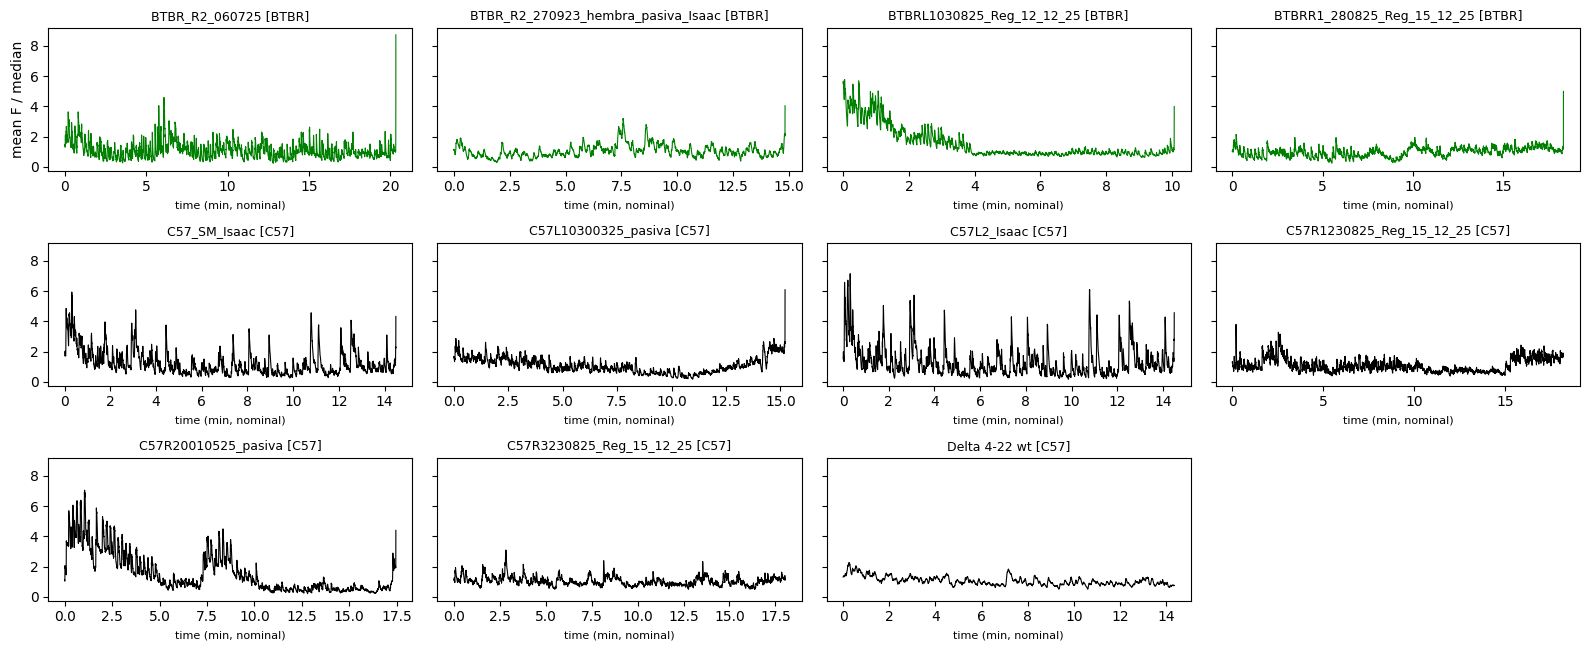

In [4]:
import matplotlib.pyplot as plt

GENO_COLOR = {'C57': 'black', 'BTBR': 'green'}

ncols = 4
nrows = int(np.ceil(len(subjects) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.2 * nrows), squeeze=False, sharey=True)

for ax, s in zip(axes.ravel(), subjects):
    F = raw[s['subject_id']]
    mean_F = np.nanmean(F, axis=0)
    t_min = np.arange(F.shape[1]) / SAMPLING_RATE / 60
    ax.plot(t_min, mean_F / np.nanmedian(mean_F), color=GENO_COLOR[s['genotype']], lw=0.8)
    ax.set_title(f"{s['subject_id']} [{s['genotype']}]", fontsize=9)
    ax.set_xlabel('time (min, nominal)', fontsize=8)
for ax in axes.ravel()[len(subjects):]:
    ax.axis('off')
axes[0, 0].set_ylabel('mean F / median')
fig.tight_layout()
plt.show()

## 3. Do the trace frames match the microscope log, and where do the stimuli fall?

The overlay in Section 6 is only meaningful if frame *i* of the CSV is frame *i* of the scope log. Below, the number of frames in the CSV is compared with the number of clean frames detected in the scope log, and every stimulus onset is checked to fall inside the trace.

The four functions are copied verbatim from `ensambles_pipeline.ipynb`.

In [5]:
def parse_scope_txt(filepath: Path) -> tuple:
    """Parses the microscope TXT file.
    Format: HH:MM:SS.microsec.frameN.flag.channel
    Returns timestamp_strs, millisec (normalized to t=0), sensors."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit = [l.strip().split('.') for l in lines[1:]]
    datasplit = [d for d in datasplit if len(d) >= 4]
    timestamp_strs = [d[0] for d in datasplit]
    millisec  = np.array([float(d[2]) for d in datasplit])
    sensors   = np.array([float(d[3]) for d in datasplit])
    millisec  = millisec - millisec[0]
    return timestamp_strs, millisec, sensors


def parse_stim_txt(filepath: Path) -> tuple:
    """Parses the stimulus TXT file.
    Format: HH:MM:SS.mmm.FLAG
      11   → stimulus onset
      0XXX → angle when it ends (4s later)
    Returns tstamp_stlog, stimuli."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit    = [l.strip().split('.') for l in lines]
    datasplit    = [d for d in datasplit if len(d) >= 3]
    tstamp_stlog = [d[0] for d in datasplit]
    stimuli      = np.array([float(d[2]) for d in datasplit])
    return tstamp_stlog, stimuli


def get_clean_frame_times(millisec: np.ndarray, sensors: np.ndarray,
                           min_interval_ms: float = 100.0) -> np.ndarray:
    """Extracts real frame times (flag==23), removing duplicates."""
    framt    = np.where(sensors == 23)[0]
    t_fram   = millisec[framt]
    ll       = np.diff(t_fram)
    idx_keep = np.where(ll > min_interval_ms)[0] + 1
    return np.insert(t_fram[idx_keep], 0, t_fram[0])

def empirical_ms_per_frame(t_hw_ms: np.ndarray, sensors: np.ndarray, min_interval_ms: float = 100.0) -> float:
    """Mediana del intervalo real entre frames (flag==23) para este animal,
    en vez de asumir el valor nominal global. Necesario porque no todos los
    animales se adquirieron a la misma tasa real (ver BTBRL1030825_Reg_12_12_25,
    ~390 ms/frame vs. ~197 ms/frame en el resto)."""
    t_clean = get_clean_frame_times(t_hw_ms, sensors, min_interval_ms)
    return float(np.median(np.diff(t_clean)))

def align_stimuli_to_frames(timestamp_strs, millisec, sensors,
                             tstamp_stlog, stimuli,
                             ms_per_frame: float = 200.0) -> np.ndarray:
    """Returns stimsnframes (n_angles, n_trials, 2):
       [:,:,0] = angle, [:,:,1] = onset frame.

    Note: n_trials is derived from angle counts only. The onset flag (11)
    is unreliable — it can register spuriously during acquisition — so its
    count is not used to determine trial number."""
    t_fram_clean = get_clean_frame_times(millisec, sensors)
    max_frame    = len(t_fram_clean) - 1

    stims_all, stim_counts = np.unique(stimuli, return_counts=True)
    stims    = stims_all[stims_all != 11]
    n_trials = int(np.min(stim_counts[stims_all != 11]))

    idx_t_stim = np.zeros((n_trials, len(stims)))

    ts_arr = np.array(timestamp_strs)
    for s, stim in enumerate(stims):
        t_stamp_idx = np.where(stimuli == stim)[0]
        t_stamp     = [tstamp_stlog[i - 1] for i in t_stamp_idx]
        for j, ts in enumerate(t_stamp):
            if j >= n_trials:
                break
            hms = list(map(int, ts.split(':')))
            hms[2] += 1
            ts2 = f"{hms[0]:02}:{hms[1]:02}:{hms[2]:02}"
            idx_bin = np.concatenate((
                np.where(ts_arr == ts)[0],
                np.where(ts_arr == ts2)[0]
            ))
            if len(idx_bin) > 0:
                idx_stim_j = np.where(
                    sensors[idx_bin[0]:idx_bin[-1]] == 4
                )[0] + idx_bin[0]
                if len(idx_stim_j) > 0:
                    idx_t_stim[j, s] = idx_stim_j[0]

    t_Stim_ms   = millisec[idx_t_stim.astype(int)]
    tf          = np.round(t_Stim_ms / ms_per_frame).astype(int)
    tf_clamped  = np.clip(tf, 0, max_frame)
    late        = t_Stim_ms - t_fram_clean[tf_clamped] > ms_per_frame
    tf[late]   += 1
    tf          = np.clip(tf, 0, max_frame).T  # (n_angles, n_trials)

    stims_tiled  = np.tile(stims[:, np.newaxis], (1, tf.shape[1]))
    stimsnframes = np.stack([stims_tiled, tf], axis=2)
    return stimsnframes

In [6]:
timing = {}
rows = []
for s in subjects:
    sid = s['subject_id']
    ts_strs, millisec, sensors = parse_scope_txt(s['files']['scope'])
    tstamp_stlog, stimuli      = parse_stim_txt(s['files']['stim'])
    t_clean = get_clean_frame_times(millisec, sensors)

    ms_per_frame_animal = empirical_ms_per_frame(millisec, sensors)  # <- nuevo: por animal, no global
    stimsnframes = align_stimuli_to_frames(ts_strs, millisec, sensors,
                                           tstamp_stlog, stimuli, ms_per_frame=ms_per_frame_animal)
    onsets = stimsnframes[:, :, 1].astype(int)
    T = raw[sid].shape[1]

    timing[sid] = {'stimsnframes': stimsnframes, 'n_frames_scope': len(t_clean)}
    rows.append({
        'subject_id':        sid,
        'genotype':          s['genotype'],
        'frames_csv':        T,
        'frames_scope_log':  len(t_clean),
        'difference':        T - len(t_clean),
        'ms_per_frame_used': round(ms_per_frame_animal, 1),   # <- nuevo: para que quede documentado por qué animal usó qué tasa
        'n_angles':          stimsnframes.shape[0],
        'n_trials':          stimsnframes.shape[1],
        'last_onset_frame':  int(onsets.max()),
        'onsets_past_trace': int((onsets + STIM_FRAMES > T).sum()),
    })
pd.DataFrame(rows).set_index('subject_id')

,genotype,frames_csv,frames_scope_log,difference,ms_per_frame_used,n_angles,n_trials,last_onset_frame,onsets_past_trace
subject_id,,,,,,,,,
BTBR_R2_060725,BTBR,6103,6071,32,200.0,8,10,5283,0
BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,4449,4370,79,200.0,8,8,4221,0
BTBRL1030825_Reg_12_12_25,BTBR,3021,3019,2,392.0,8,10,2694,0
BTBRR1_280825_Reg_15_12_25,BTBR,5500,5462,38,200.0,8,10,5279,0
C57_SM_Isaac,C57,4350,4319,31,200.0,8,8,4220,0
C57L10300325_pasiva,C57,4564,4497,67,200.0,8,8,4215,0
C57L2_Isaac,C57,4350,4272,78,200.0,8,8,4221,0
C57R1230825_Reg_15_12_25,C57,5466,5596,-130,200.0,8,10,5469,1
C57R20010525_pasiva,C57,5240,5208,32,200.0,8,8,4215,0


In [7]:
timing = {}
rows = []
for s in subjects:
    sid = s['subject_id']
    ts_strs, millisec, sensors = parse_scope_txt(s['files']['scope'])
    tstamp_stlog, stimuli      = parse_stim_txt(s['files']['stim'])
    t_clean = get_clean_frame_times(millisec, sensors)

    stimsnframes = align_stimuli_to_frames(ts_strs, millisec, sensors,
                                           tstamp_stlog, stimuli, ms_per_frame=MS_PER_FRAME)
    onsets = stimsnframes[:, :, 1].astype(int)
    T = raw[sid].shape[1]

    timing[sid] = {'stimsnframes': stimsnframes, 'n_frames_scope': len(t_clean)}
    rows.append({
        'subject_id':        sid,
        'genotype':          s['genotype'],
        'frames_csv':        T,
        'frames_scope_log':  len(t_clean),
        'difference':        T - len(t_clean),
        'n_angles':          stimsnframes.shape[0],
        'n_trials':          stimsnframes.shape[1],
        'last_onset_frame':  int(onsets.max()),
        'onsets_past_trace': int((onsets + STIM_FRAMES > T).sum()),
    })
pd.DataFrame(rows).set_index('subject_id')

,genotype,frames_csv,frames_scope_log,difference,n_angles,n_trials,last_onset_frame,onsets_past_trace
subject_id,,,,,,,,
BTBR_R2_060725,BTBR,6103,6071,32,8,10,5283,0
BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,4449,4370,79,8,8,4221,0
BTBRL1030825_Reg_12_12_25,BTBR,3021,3019,2,8,10,3018,35
BTBRR1_280825_Reg_15_12_25,BTBR,5500,5462,38,8,10,5279,0
C57_SM_Isaac,C57,4350,4319,31,8,8,4220,0
C57L10300325_pasiva,C57,4564,4497,67,8,8,4215,0
C57L2_Isaac,C57,4350,4272,78,8,8,4221,0
C57R1230825_Reg_15_12_25,C57,5466,5596,-130,8,10,5469,1
C57R20010525_pasiva,C57,5240,5208,32,8,8,4215,0


In [8]:
def empirical_ms_per_frame(t_hw_ms: np.ndarray, sensors: np.ndarray, min_interval_ms: float = 100.0) -> float:
    """Mediana del intervalo real entre frames (flag==23), usando el mismo
    filtro de umbral que get_clean_frame_times, en vez de asumir el valor nominal."""
    t_clean = get_clean_frame_times(t_hw_ms, sensors, min_interval_ms)
    return float(np.median(np.diff(t_clean)))

In [9]:
ms_per_frame_animal = empirical_ms_per_frame(millisec, sensors)
stimsnframes = align_stimuli_to_frames(ts_strs, millisec, sensors,
                                        tstamp_stlog, stimuli,
                                        ms_per_frame=ms_per_frame_animal)

In [10]:
scope_file = [s for s in subjects if s['subject_id'] == 'C57R1230825_Reg_15_12_25'][0]['files']['scope']
ts_strs, millisec, sensors = parse_scope_txt(scope_file)

frame_idx = np.where(sensors == 23)[0]
t_frame = millisec[frame_idx]
diffs = np.diff(t_frame)

print('Eventos flag=23 crudos (sin filtrar):', len(frame_idx))
print('Diferencias negativas (¿reinicio del contador de hardware?):', (diffs < 0).sum())
print('Frames "limpios" tras el filtro de 100ms:', len(get_clean_frame_times(millisec, sensors)))
print(pd.Series(diffs).describe())

Eventos flag=23 crudos (sin filtrar): 33956
Diferencias negativas (¿reinicio del contador de hardware?): 0
Frames "limpios" tras el filtro de 100ms: 5596
count    33955.000000
mean        33.219703
std         88.195321
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max       9171.000000
dtype: float64


In [11]:
kept = np.diff(get_clean_frame_times(millisec, sensors))
print(pd.Series(kept).describe())
print(pd.Series(kept).value_counts(bins=8).sort_index())

count    5595.000000
mean      201.604111
std       120.062167
min       196.000000
25%       199.000000
50%       200.000000
75%       201.000000
max      9179.000000
dtype: float64
(187.016, 1318.875]    5594
(1318.875, 2441.75]       0
(2441.75, 3564.625]       0
(3564.625, 4687.5]        0
(4687.5, 5810.375]        0
(5810.375, 6933.25]       0
(6933.25, 8056.125]       0
(8056.125, 9179.0]        1
Name: count, dtype: int64


In [12]:
scope_ok = [s for s in subjects if s['subject_id'] == 'BTBR_R2_060725'][0]['files']['scope']
_, millisec_ok, sensors_ok = parse_scope_txt(scope_ok)
kept_ok = np.diff(get_clean_frame_times(millisec_ok, sensors_ok))
print(pd.Series(kept_ok).describe())
print(pd.Series(kept_ok).value_counts(bins=8).sort_index())

count    6070.000000
mean      200.001483
std         2.289516
min       196.000000
25%       199.000000
50%       200.000000
75%       201.000000
max       214.000000
dtype: float64
(195.981, 198.25]    1354
(198.25, 200.5]      2747
(200.5, 202.75]      1596
(202.75, 205.0]       128
(205.0, 207.25]       108
(207.25, 209.5]        82
(209.5, 211.75]        40
(211.75, 214.0]        15
Name: count, dtype: int64


In [13]:
scope_c57 = [s for s in subjects if s['subject_id'] == 'C57R1230825_Reg_15_12_25'][0]['files']['scope']
stim_c57  = [s for s in subjects if s['subject_id'] == 'C57R1230825_Reg_15_12_25'][0]['files']['stim']
ts_strs, millisec, sensors = parse_scope_txt(scope_c57)
tstamp_stlog, stimuli = parse_stim_txt(stim_c57)

t_clean = get_clean_frame_times(millisec, sensors)
print('Duración total según scope (min):', t_clean[-1] / 1000 / 60)
print('Frames en CSV / tasa nominal (min):', 5466 * 0.2 / 60)
print('Último timestamp de estímulo:', tstamp_stlog[-1])

Duración total según scope (min): 18.79958333333333
Frames en CSV / tasa nominal (min): 18.220000000000002
Último timestamp de estímulo: 09:16:23


In [14]:
c57_subject = [s for s in subjects if s['subject_id'] == 'C57R1230825_Reg_15_12_25'][0]
ts_strs, millisec, sensors = parse_scope_txt(c57_subject['files']['scope'])
tstamp_stlog, stimuli = parse_stim_txt(c57_subject['files']['stim'])
stimsnframes = align_stimuli_to_frames(ts_strs, millisec, sensors, tstamp_stlog, stimuli, ms_per_frame=MS_PER_FRAME)

T = raw['C57R1230825_Reg_15_12_25'].shape[1]
onsets = stimsnframes[:, :, 1].astype(int)
angles = stimsnframes[:, :, 0].astype(int)

out_of_range = np.where(onsets + STIM_FRAMES > T)
for a_i, t_i in zip(*out_of_range):
    print(f"Ángulo: {angles[a_i, t_i]}°, trial #{t_i}, onset_frame={onsets[a_i, t_i]}, "
          f"necesitaría hasta frame {onsets[a_i, t_i] + STIM_FRAMES}, pero el trazo solo tiene {T} frames.")

Ángulo: 270°, trial #9, onset_frame=5469, necesitaría hasta frame 5489, pero el trazo solo tiene 5466 frames.


**Open:** any row with a non-zero `difference` needs an explicit decision (trim, or find where frames were lost) before its overlay in Section 6 is trusted.

## 4. How should raw F be normalized before sorting?

**Assumption (open):** F0 is a sliding low percentile per neuron. That removes slow drift and bleaching without needing a stimulus-free window. The window and percentile below are working values for a first pass, not literature values (TODO: justify against the drift plot in Section 2 and cite). The trial-based F0 used for OSI/DSI does not apply here, because the continuous trace has no dedicated pre-stimulus window.

The function raises on NaN and on non-positive baselines instead of patching them: dF/F divides by F0.

In [15]:
rows = []
for s in subjects:
    sid = s['subject_id']
    F = raw[sid]
    F0 = percentile_filter(F, percentile=BASELINE_PCTL, size=(1, window_frames), mode='nearest')
    rows.append({
        'subject_id':           sid,
        'genotype':             s['genotype'],
        'n_neurons':            F.shape[0],
        'neurons_with_F0_le0':  int((F0 <= 0).any(axis=1).sum()),
        'neurons_median_F_le0': int((np.median(F, axis=1) <= 0).sum()),
        'frac_F0_le0':          float(np.mean(F0 <= 0)),
        'frac_F_le0':           float(np.mean(F <= 0)),
        'F_min':                F.min(),
        'F_p1':                 np.percentile(F, 1),
        'F_median':             np.median(F),
    })
pd.DataFrame(rows).set_index('subject_id').round(3)

NameError: name 'percentile_filter' is not defined

## 5. What ordering does Rastermap find in each animal?

**Inputs.** All neurons, not only the responsive ones. Assumption: selecting neurons by their evoked response would bias the ordering toward stimulus-locked structure, which is what we want to test rather than build in. Rastermap z-scores each neuron across time internally.

**Two fits per animal, differing in `mean_time`.** With `mean_time=True` (the default in rastermap 1.0) the population mean at each timepoint is projected out before sorting. That removes exactly the population-wide coactivity that the SCE analysis is built on, so the ordering can no longer reflect it. With `mean_time=False` that component stays in. Neither is wrong; they answer different questions, so both are kept.

**Sorting mode.** `locality=0` and `time_lag_window=0` (global sorting, library defaults). The values in the Rastermap tutorial (`locality=0.75`, `time_lag_window=5`) are meant for sequence finding and are not used here.

**Open:** how rastermap 1.0 behaves when a subject has fewer neurons than `n_PCs` or `n_clusters` was not verified from its source. The wrapper caps both by the data size; check the smallest recording.

In [ ]:
from rastermap import Rastermap

RM_PARAMS = dict(n_clusters=100, n_PCs=200, locality=0.0, time_lag_window=0, grid_upsample=10)


def fit_rastermap(X: np.ndarray, mean_time: bool, params: dict = RM_PARAMS) -> Rastermap:
    n, t = X.shape
    p = dict(params)
    p['n_PCs']      = int(min(p['n_PCs'], n - 1, t - 1))
    p['n_clusters'] = int(min(p['n_clusters'], max(n // 3, 2)))
    return Rastermap(mean_time=mean_time, verbose=False, **p).fit(X.astype('float32'))


rmap = {}
for s in subjects:
    sid = s['subject_id']
    rmap[sid] = {mt: fit_rastermap(dff[sid], mean_time=mt) for mt in (True, False)}
    print(f"{sid} [{s['genotype']}]: {dff[sid].shape[0]} neurons, "
          f"n_PCs used = {rmap[sid][True].n_PCs}")

## 6. Does the ordering follow the stimulus?

Each raster shows the sorted, z-scored activity (`X_embedding`: neurons binned along the sorted axis, time on x). The coloured strip above marks each stimulus presentation, one colour per angle. If blocks of neurons switch on with particular colours, the ordering tracks orientation or direction; if they switch on across colours, it tracks something shared by all stimuli; if they are active between presentations, it tracks activity that the stimulus does not drive.

Time is in seconds at the nominal 5 Hz.

In [ ]:
def plot_raster(sid, genotype, models, stimsnframes, save=True):
    T = dff[sid].shape[1]
    angles = np.unique(stimsnframes[:, :, 0])
    cmap = plt.cm.hsv
    color_of = {a: cmap(i / len(angles)) for i, a in enumerate(angles)}

    fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True,
                             gridspec_kw={'height_ratios': [0.25, 3, 0.25, 3]})
    for k, (mt, strip_ax, ax) in enumerate(zip((True, False), axes[[0, 2]], axes[[1, 3]])):
        for a_i, a in enumerate(angles):
            for onset in stimsnframes[a_i, :, 1].astype(int):
                strip_ax.axvspan(onset / SAMPLING_RATE, (onset + STIM_FRAMES) / SAMPLING_RATE,
                                 color=color_of[a], lw=0)
        strip_ax.set_yticks([]); strip_ax.set_ylim(0, 1)
        Xe = models[mt].X_embedding
        ax.imshow(Xe, vmin=0, vmax=1.5, cmap='gray_r', aspect='auto',
                  extent=[0, T / SAMPLING_RATE, Xe.shape[0], 0])
        ax.set_ylabel(f'sorted neurons\n(mean_time={mt})')
    axes[3].set_xlabel('time (s, nominal)')
    axes[0].set_title(f'{sid} [{genotype}], {dff[sid].shape[0]} neurons', fontsize=10)
    handles = [plt.Rectangle((0, 0), 1, 1, color=color_of[a]) for a in angles]
    axes[0].legend(handles, [str(int(a)) for a in angles], ncol=len(angles),
                   fontsize=7, loc='lower right', bbox_to_anchor=(1, 1.0), frameon=False)
    fig.tight_layout()
    if save:
        fig.savefig(OUTPUT_DIR / f'{sid}_rastermap.png', dpi=200)
    plt.show()


for s in subjects:
    sid = s['subject_id']
    plot_raster(sid, s['genotype'], rmap[sid], timing[sid]['stimsnframes'])

## Open items

- Baseline window and percentile (Section 4) are working values; they have not been checked against the drift in Section 2 for every animal.
- Empirical frame interval (~190 ms) vs nominal 200 ms: it rescales the time axis by about 5% and matters for any `time_lag_window > 0`.
- All neurons vs responsive only: kept as all; not compared.
- Nothing here is quantified yet. A per-animal summary of the embedding (for example, how much sorted-neuron activity is explained by stimulus timing) has to be defined before comparing genotypes.